In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.interpolate import LSQUnivariateSpline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [3]:
# 1. LOAD DATA
strain = pd.read_csv("strain.csv")
stress = pd.read_csv("stress.csv")
strain = strain[[c for c in strain.columns if not c.startswith('Unnamed')]]
stress = stress[[c for c in stress.columns if not c.startswith('Unnamed')]]

In [4]:
strain_0 = strain.values[:, 0]
strain_400 = strain.values[:, 1]
strain_600 = strain.values[:, 2]
stress_0 = stress.values[:, 0]
stress_400 = stress.values[:, 1]
stress_600 = stress.values[:, 2]

In [5]:
sorting_indices = np.argsort(strain_0)
x_0 = strain_0[sorting_indices]
y_0 = stress_0[sorting_indices]
sorting_indices = np.argsort(strain_400)
x_400 = strain_400[sorting_indices]
y_400 = stress_400[sorting_indices]
sorting_indices = np.argsort(strain_600)
x_600 = strain_600[sorting_indices]
y_600 = stress_600[sorting_indices]

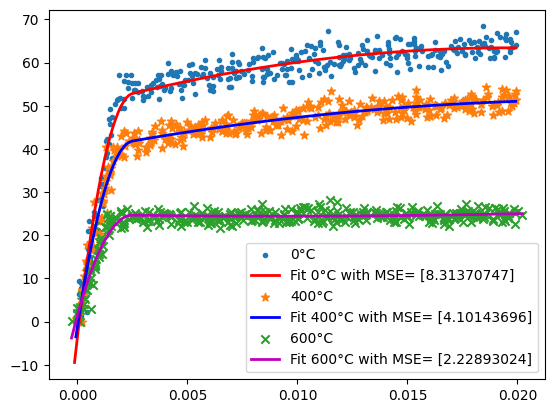

In [6]:
# regression using quadratic spline
# inner support point manually chosen to be at the yield point
inner_support_points_x = [0.0025]

spl_0 = LSQUnivariateSpline(x_0, y_0, inner_support_points_x, k=2)
MSE_0 = ((y_0 - spl_0(x_0))**2).sum() / y_0.shape

spl_400 = LSQUnivariateSpline(x_400, y_400, inner_support_points_x, k=2)
MSE_400 = ((y_400 - spl_400(x_400))**2).sum() / y_400.shape

spl_600 = LSQUnivariateSpline(x_600, y_600, inner_support_points_x, k=2)
MSE_600 = ((y_600 - spl_600(x_600))**2).sum() / y_600.shape


# 1. Scatter points for all three
plt.scatter(x_0, y_0, marker='.', label='0°C')
plt.plot(x_0, spl_0(x_0), lw=2, c='r',label=f'Fit 0°C with MSE= {MSE_0}')
plt.scatter(x_400, y_400, marker='*', label='400°C')
plt.plot(x_400, spl_400(x_400), lw=2, c='b',label=f'Fit 400°C with MSE= {MSE_400}')
plt.scatter(x_600, y_600, marker='x',label='600°C' )
plt.plot(x_600, spl_600(x_600), lw=2, c='m',label=f'Fit 600°C with MSE= {MSE_600}')


plt.legend()
plt.show()
    



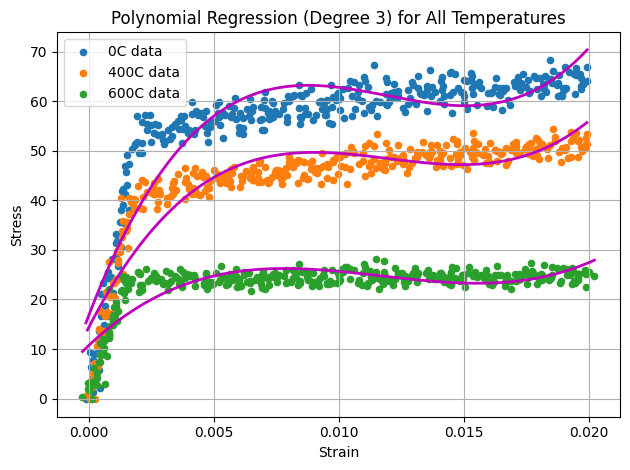

In [22]:
datasets = {
    "0C": (x_0, y_0),
    "400C": (x_400, y_400),
    "600C": (x_600, y_600),
}

models = {}

for label, (x, y) in datasets.items():
    x = x.reshape(-1, 1)
    poly = PolynomialFeatures(degree=3, include_bias=False)
    X_poly = poly.fit_transform(x)

    model = LinearRegression()
    model.fit(X_poly, y)

    models[label] = (poly, model)

    # Smooth grid for plotting
    x_grid = np.linspace(x.min(), x.max(), 500).reshape(-1, 1)
    X_grid_poly = poly.transform(x_grid)
    y_pred = model.predict(X_grid_poly)

    # Plot data + fit
    plt.scatter(x, y, s=20, label=f"{label} data")
    plt.plot(x_grid, y_pred, linewidth=2, c='m')

plt.xlabel("Strain")
plt.ylabel("Stress")
plt.title("Polynomial Regression (Degree 3) for All Temperatures")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#for Prediction Stress=spl_temp(strain)